In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

/home/noah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [34]:
# Parameters
N_s   = 100
sigma = (2*np.pi/N_s) * 1   # tuning width (neurons wide)
h_b   = 0
beta  = 200
v0    = 10
dt    = 0.3
L     = 1000
nu    = 1
h0    = 0.05
target = 0

In [35]:
# Node positions and connectivity
alpha = np.array([2*np.pi*i/N_s for i in range(N_s)])

J = np.zeros((N_s, N_s))
for i in range(N_s):
    for j in range(N_s):
        J[i, j] = np.cos(alpha[i] - alpha[j]) - nu

In [36]:
def plot_ring(u, alpha, beta):
    firing_rate  = np.maximum(0, np.tanh(beta * u))
    alpha_closed = np.append(alpha, alpha[0])
    fr_closed    = np.append(firing_rate, firing_rate[0])

    r_base = 0.5
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    ax.fill_between(alpha_closed, r_base, r_base + fr_closed * 0.4, alpha=0.4, color='blue')
    ax.plot(alpha_closed, r_base + fr_closed * 0.4, color='blue', linewidth=1.5)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([])
    ax.set_title('Firing rate around the ring')
    plt.tight_layout()
    plt.show()

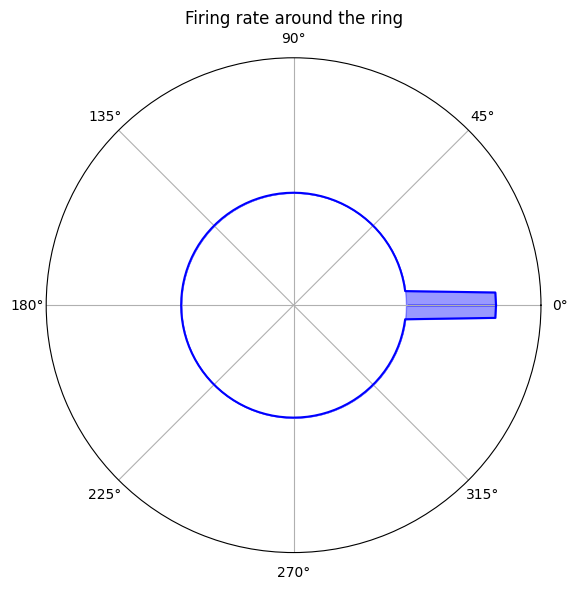

In [37]:
# Static RAN run
u      = np.zeros(N_s)
u_next = np.zeros(N_s)
T      = 500

for t in range(T):
    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(alpha[i] - target), np.cos(alpha[i] - target))
        h[i] = (h0 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += J[i][j] * np.tanh(beta * u[j])
        u_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = u_next

    v = np.zeros(2)
    for i in range(N_s):
        v += max(0, np.tanh(beta * u[i])) * np.array([np.cos(alpha[i]), np.sin(alpha[i])])
    v *= v0 / N_s

plot_ring(u, alpha, beta)

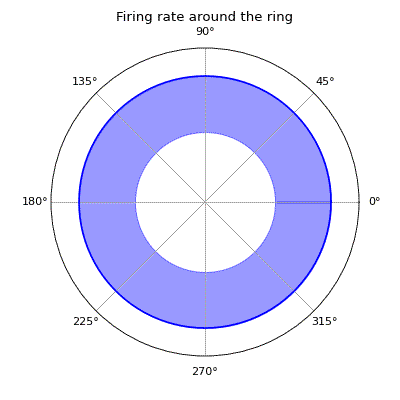

In [38]:
# Warm up network to settled bump state before recording
u      = np.zeros(N_s)
u_next = np.zeros(N_s)
for _ in range(500):
    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(alpha[i] - target), np.cos(alpha[i] - target))
        h[i] = (h0 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += J[i][j] * np.tanh(beta * u[j])
        u_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = u_next

# Pre-compute all animation frames from settled state
frames = []
for t in range(150):
    if (t > 60):
        moving_target = ((150 - t / 100) % (2 * np.pi))
    else:
        moving_target = (t / 100) % (2 * np.pi)

    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(alpha[i] - moving_target), np.cos(alpha[i] - moving_target))
        h[i] = (h0 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += J[i][j] * np.tanh(beta * u[j])
        u_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = u_next
    frames.append(np.maximum(0, np.tanh(beta * u.copy())))

from matplotlib.animation import PillowWriter
from IPython.display import Image

r_base       = 0.5
alpha_closed = np.append(alpha, alpha[0])

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
fr0  = np.append(frames[0], frames[0][0])
fill = [ax.fill_between(alpha_closed, r_base, r_base + fr0 * 0.4, alpha=0.4, color='blue')]
line, = ax.plot(alpha_closed, r_base + fr0 * 0.4, color='blue', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_yticks([])
ax.set_title('Firing rate around the ring')

writer = PillowWriter(fps=20)
with writer.saving(fig, 'ran_animation.gif', dpi=80):
    for frame_data in frames:
        fill[0].remove()
        fr = np.append(frame_data, frame_data[0])
        fill[0] = ax.fill_between(alpha_closed, r_base, r_base + fr * 0.4, alpha=0.4, color='blue')
        line.set_ydata(r_base + fr * 0.4)
        writer.grab_frame()

plt.close()
Image('ran_animation.gif')